In [1]:
import pandas as pd
import numpy as np
import os
import glob
import gc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.metrics import AUC
import matplotlib.pyplot as plt

In [10]:
input_dir = "../patient_labeled_data"
csv_files = glob.glob(os.path.join(input_dir, "*.csv"))

features = [
    'Solar8000/HR', 'Solar8000/ART_SBP', 'Solar8000/ART_DBP', 
    'Solar8000/ART_MBP', 'Solar8000/PLETH_SPO2', 'Solar8000/RR_CO2', 
    'Solar8000/ETCO2', 'Primus/FIO2', 'Solar8000/BT'
]

train_files, test_files = train_test_split(csv_files, test_size=0.2, random_state=42)
print(f"Train patients: {len(train_files)} | Test patients: {len(test_files)}")

Train patients: 80 | Test patients: 20


In [11]:
# Memory Optimization
def create_windows(file_list, target_col, window_size=600, stride=10):
    X_list, y_list = [], []
    
    for file in file_list:
        df = pd.read_csv(file)
        df[features] = df[features].ffill().fillna(0)
        
        data = df[features].values
        labels = df[target_col].values
        
        for i in range(0, len(data) - window_size, stride):
            X_list.append(data[i : i + window_size])
            y_list.append(labels[i + window_size])
            
    return np.array(X_list), np.array(y_list)

In [12]:
def build_1d_cnn(input_shape):
    model = Sequential([
        Conv1D(filters=64, kernel_size=10, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(filters=128, kernel_size=10, activation='relu'),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),
        
        GlobalAveragePooling1D(),
        
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[AUC(name='auroc')])
    return model


      STARTING PIPELINE FOR: Future_Hypotension

Building data windows...
Scaling features...


c:\Users\Raj Jaiswal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model...
Epoch 1/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - auroc: 0.8232 - loss: 0.4810 - val_auroc: 0.7248 - val_loss: 0.6741
Epoch 2/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - auroc: 0.8913 - loss: 0.3892 - val_auroc: 0.7082 - val_loss: 0.8345
Epoch 3/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - auroc: 0.9249 - loss: 0.3286 - val_auroc: 0.7256 - val_loss: 0.9377
Epoch 4/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - auroc: 0.9472 - loss: 0.2788 - val_auroc: 0.7131 - val_loss: 1.2078
Epoch 5/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - auroc: 0.9597 - loss: 0.2451 - val_auroc: 0.7092 - val_loss: 1.4239
Epoch 6/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - auroc: 0.9671 - loss: 0.2223 - val_auroc: 0.7034 - val_loss: 1.5947
Epoch 7/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - auroc: 0.9719 - loss: 0.2051 - val_auroc: 0.7086 - val_loss: 1.5129
Epoch 8/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - auroc: 0.9754 - loss: 0.1921 - val_auroc: 0.7017 - val_los

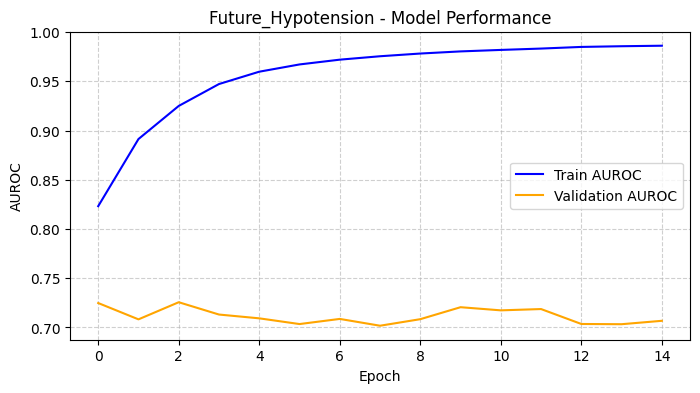


      STARTING PIPELINE FOR: Future_Tachycardia

Building data windows...
Scaling features...


c:\Users\Raj Jaiswal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model...
Epoch 1/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - auroc: 0.8633 - loss: 0.2860 - val_auroc: 0.8563 - val_loss: 0.1917
Epoch 2/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - auroc: 0.9454 - loss: 0.1987 - val_auroc: 0.8852 - val_loss: 0.1925
Epoch 3/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - auroc: 0.9696 - loss: 0.1535 - val_auroc: 0.8133 - val_loss: 0.2383
Epoch 4/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - auroc: 0.9789 - loss: 0.1295 - val_auroc: 0.8175 - val_loss: 0.2434
Epoch 5/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - auroc: 0.9852 - loss: 0.1082 - val_auroc: 0.7585 - val_loss: 0.2962
Epoch 6/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 62ms/step - auroc: 0.9878 - loss: 0.0980 - val_auroc: 0.7784 - val_loss: 0.3176
Epoch 7/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - auroc: 0.9893 - loss: 0.0914 - val_auroc: 0.7705 - val_loss: 0.3514
Epoch 8/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 46s 61ms/step - auroc: 0.9908 - loss: 0.0850 - val_auroc: 0.7213 - val_los

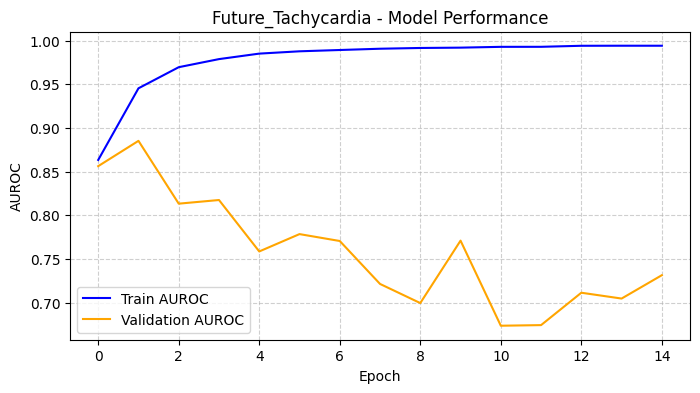


      STARTING PIPELINE FOR: Future_Hypoxia

Building data windows...
Scaling features...


c:\Users\Raj Jaiswal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training model...
Epoch 1/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - auroc: 0.8614 - loss: 0.1563 - val_auroc: 0.6398 - val_loss: 0.3916
Epoch 2/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 48s 64ms/step - auroc: 0.9486 - loss: 0.1067 - val_auroc: 0.6434 - val_loss: 0.4199
Epoch 3/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - auroc: 0.9713 - loss: 0.0832 - val_auroc: 0.7197 - val_loss: 0.4409
Epoch 4/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - auroc: 0.9821 - loss: 0.0676 - val_auroc: 0.6491 - val_loss: 0.5644
Epoch 5/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - auroc: 0.9876 - loss: 0.0566 - val_auroc: 0.6705 - val_loss: 0.7611
Epoch 6/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - auroc: 0.9912 - loss: 0.0465 - val_auroc: 0.7165 - val_loss: 0.5614
Epoch 7/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 47s 63ms/step - auroc: 0.9918 - loss: 0.0430 - val_auroc: 0.6286 - val_loss: 0.8362
Epoch 8/15
753/753 ━━━━━━━━━━━━━━━━━━━━ 48s 63ms/step - auroc: 0.9935 - loss: 0.0382 - val_auroc: 0.6394 - val_los

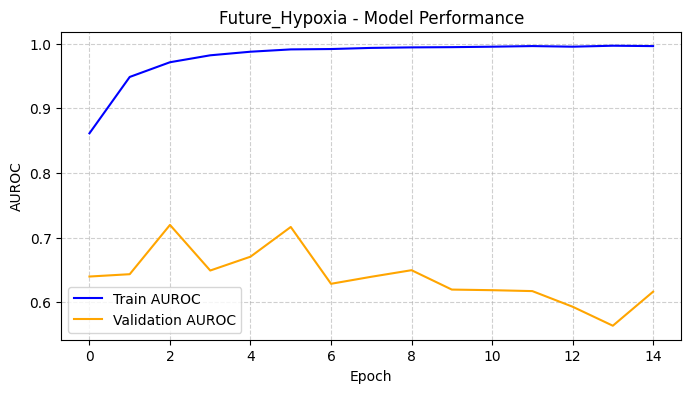


All targets processed successfully!


In [13]:
targets = ['Future_Hypotension', 'Future_Tachycardia', 'Future_Hypoxia']

for target in targets:
    print(f"\n=======================================================")
    print(f"      STARTING PIPELINE FOR: {target}")
    print(f"=======================================================\n")
    
    print("Building data windows...")
    X_train, y_train = create_windows(train_files, target, stride=10)
    X_test, y_test = create_windows(test_files, target, stride=10)
    
    print("Scaling features...")
    scaler = StandardScaler()
    num_train, window_len, num_features = X_train.shape
    num_test = X_test.shape[0]
    
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, num_features)).reshape(num_train, window_len, num_features)
    X_test_scaled = scaler.transform(X_test.reshape(-1, num_features)).reshape(num_test, window_len, num_features)
    
    del X_train, X_test
    gc.collect()
    
    input_shape = (window_len, num_features)
    model = build_1d_cnn(input_shape)
    
    print("Training model...")
    history = model.fit(
        X_train_scaled, y_train,
        epochs=15, 
        batch_size=128,
        validation_split=0.1, 
        verbose=1
    )
    
    print("\nEvaluating on unseen test patients...")
    test_loss, test_auroc = model.evaluate(X_test_scaled, y_test, verbose=0)
    print(f">>> FINAL TEST AUROC FOR {target}: {test_auroc:.4f} <<<\n")
    
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['auroc'], label='Train AUROC', color='blue')
    plt.plot(history.history['val_auroc'], label='Validation AUROC', color='orange')
    plt.title(f'{target} - Model Performance')
    plt.ylabel('AUROC')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    
    del X_train_scaled, X_test_scaled, y_train, y_test, model
    gc.collect()
    
print("\nAll targets processed successfully!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_forecast(file_path, target_col, current_model, current_scaler, feature_cols):
    df = pd.read_csv(file_path)[feature_cols + [target_col]].ffill().fillna(0)
    data, labels = df[feature_cols].values, df[target_col].values
    
    X = np.array([data[i : i + 600] for i in range(0, len(data) - 600, 10)])
    y = np.array([labels[i + 600] for i in range(0, len(data) - 600, 10)])
    
    X_scaled = current_scaler.transform(X.reshape(-1, len(feature_cols))).reshape(X.shape)
    preds = current_model.predict(X_scaled, verbose=0).flatten()
    
    t = (np.arange(len(y)) * 10 / 60.0) + 10 
    
    plt.figure(figsize=(10, 3))
    plt.fill_between(t, 0, y, color='red', alpha=0.2, label='Actual Event Occurs')
    plt.plot(t, preds, color='blue', lw=2, label='Predicted Risk (0-1)')
    plt.axhline(0.5, color='gray', linestyle=':')
    plt.title(f'10-Minute Forecast: {target_col.split("_")[1]}')
    plt.xlabel('Time (Minutes)')
    plt.legend(loc='upper right')
    plt.show()

plot_forecast(test_files[0], 'Future_Hypoxia', model, scaler, features)
plot_forecast(test_files[0], 'Future_Hypotension', model, scaler, features)
plot_forecast(test_files[0], 'Future_Tachycardia', model, scaler, features)

NameError: name 'model' is not defined